# Klassifikation - Finaler Workflow für CatBoost

## Schritt 1 — Datenvorbereitung
Die Spalte "damage" wird isoliert und aus den Features entfernt (wird später für die benutzerdefinierte Metrik benötigt). Die Daten werden in Trainings- (80%) und Testdaten (20%) aufgeteilt, wobei die Stratifizierung beibehalten wird (stratify=y)

In [1]:
# %pip install catboost

In [2]:
# Imports (gekürzt für Dokumentation)
import numpy as np
import pandas as pd
import joblib
import os
from datetime import datetime
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, precision_recall_curve
from imblearn.over_sampling import SMOTE
from catboost import CatBoostClassifier
from pipeline.data_pipeline import preprocessor, X, y

# Damage-Spalte isolieren und entfernen
damage_series = X['damage'].copy()
X = X.drop(columns=['damage'])

# Train/Test-Split mit Stratifikation
X_train, X_test, y_train, y_test, damage_train, damage_test = train_test_split(
    X, y, damage_series, test_size=0.2, random_state=42, stratify=y
)

## Schritt 2 — Custom Objective Function

In [3]:
# Ziel: - Summe Schaden FN + 5 * TP - 10 * FP
def custom_objective_score(y_true, y_pred, damage_series):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm.ravel()
    fn_mask = (y_true == 1) & (y_pred == 0)
    sum_damage_fn = damage_series[fn_mask].sum()
    score = -sum_damage_fn + (5 * TP) - (10 * FP)
    return float(score)

## Schritt 3 — Randomisierte Hyperparametersuche mit SMOTE
randomized_search_with_smote führt eine randomisierte Suche mit Kreuzvalidierung durch. Sie verwendet StratifiedKFold für die Kreuzvalidierung (3-fach), führt SMOTE-Oversampling durch (20% der Minderheitsklasse), nutzt die benutzerdefinierte Metrik zur Bewertung und testet verschiedene Kombinationen von Hyperparametern für CatBoost (15 Iterationen).

In [4]:
def randomized_search_with_smote(model_class, param_grid, preprocessor, 
                                  X, y, damage_series, 
                                  model_fixed_params=None, 
                                  n_iter=15, cv_splits=3, random_state=42):     # Anzahl Iterationen: n_iter=x ; Anzahl Kreizvalidierungen: cv_splits=x
    
    rng = np.random.default_rng(seed=random_state)
    skf = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=random_state)
    best_score = -np.inf
    best_params = None
    param_grid_items = list(param_grid.items())

    for iteration in range(n_iter):
        params = {key: rng.choice(list(values)) for key, values in param_grid_items}
        full_params = {**params}
        if model_fixed_params:
            full_params.update(model_fixed_params)

        print(f"\n➡️ Iteration {iteration+1}: teste Parameter {full_params}")
        fold_scores = []

        for train_idx, valid_idx in skf.split(X, y):
            X_train_fold, X_valid_fold = X.iloc[train_idx], X.iloc[valid_idx]
            y_train_fold, y_valid_fold = y.iloc[train_idx], y.iloc[valid_idx]
            damage_valid = damage_series.iloc[valid_idx]

            # Preprocessing und Oversampling
            X_train_prep = preprocessor.fit_transform(X_train_fold)
            X_valid_prep = preprocessor.transform(X_valid_fold)

            smote = SMOTE(sampling_strategy=0.2, random_state=random_state)
            X_resampled, y_resampled = smote.fit_resample(X_train_prep, y_train_fold)

            model = model_class(**full_params)
            model.fit(X_resampled, y_resampled)
            y_pred = model.predict(X_valid_prep)
            score = custom_objective_score(y_valid_fold.reset_index(drop=True), y_pred, damage_valid.reset_index(drop=True))
            fold_scores.append(score)

        mean_score = np.mean(fold_scores)
        print(f"  ➡️ Durchschnittlicher CV-Score: {mean_score:.2f}")

        if mean_score > best_score:
            best_score = mean_score
            best_params = full_params

    print("\n✅ Beste Parameter gefunden!")
    print(f"✅ Parameter: {best_params}")
    print(f"✅ CV-Score: {best_score:.2f}")
    return best_params, best_score

## Schritt 4 — Parameterräume für CatBoost

In [5]:
param_grid_cat = {
    'iterations': [250, 300, 350],
    'learning_rate': [0.07, 0.08, 0.09],
    'depth': [4, 5, 6]
}

## Schritt 5 — Hyperparameter-Optimierung

In [6]:
best_params_cat, best_score_cat = randomized_search_with_smote(
    model_class=CatBoostClassifier,
    param_grid=param_grid_cat,
    preprocessor=preprocessor,
    X=X_train,
    y=y_train,
    damage_series=damage_train,
    model_fixed_params={'verbose': 0, 'random_state': 42}
)


➡️ Iteration 1: teste Parameter {'iterations': np.int64(250), 'learning_rate': np.float64(0.09), 'depth': np.int64(5), 'verbose': 0, 'random_state': 42}


c:\Users\lol--\miniconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\lol--\miniconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\lol--\miniconda3\Lib\subprocess.py", line 550, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\lol--\miniconda3\Lib\subprocess.py", line 1028, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\lol--\miniconda3\Lib\subprocess.py", line 1540, in _execute_child
    hp, ht, pid, tid = _winapi.Crea

  ➡️ Durchschnittlicher CV-Score: -6742.58

➡️ Iteration 2: teste Parameter {'iterations': np.int64(300), 'learning_rate': np.float64(0.08), 'depth': np.int64(6), 'verbose': 0, 'random_state': 42}
  ➡️ Durchschnittlicher CV-Score: -6642.04

➡️ Iteration 3: teste Parameter {'iterations': np.int64(250), 'learning_rate': np.float64(0.09), 'depth': np.int64(4), 'verbose': 0, 'random_state': 42}
  ➡️ Durchschnittlicher CV-Score: -6675.06

➡️ Iteration 4: teste Parameter {'iterations': np.int64(250), 'learning_rate': np.float64(0.08), 'depth': np.int64(6), 'verbose': 0, 'random_state': 42}
  ➡️ Durchschnittlicher CV-Score: -6662.89

➡️ Iteration 5: teste Parameter {'iterations': np.int64(350), 'learning_rate': np.float64(0.09), 'depth': np.int64(6), 'verbose': 0, 'random_state': 42}
  ➡️ Durchschnittlicher CV-Score: -6714.79

➡️ Iteration 6: teste Parameter {'iterations': np.int64(350), 'learning_rate': np.float64(0.08), 'depth': np.int64(4), 'verbose': 0, 'random_state': 42}
  ➡️ Durchschni

## Schritt 6 — Finales Training auf dem vollständigen Trainingsset
Das beste Modell aus der Parametersuche wird auf den gesamten Trainingsdaten trainiert. Erneut wird SMOTE für das Klassenausgleich verwendet.

In [7]:
# Preprocessing und Oversampling auf Gesamtdatensatz
X_train_prep = preprocessor.fit_transform(X_train)
smote = SMOTE(sampling_strategy=0.2, random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_prep, y_train)

# Finales Modelltraining
final_cat = CatBoostClassifier(**best_params_cat)
final_cat.fit(X_train_res, y_train_res)


## Schritt 7 — Evaluation auf Testset
Standardmetriken werden berechnet (Classification Report, Confusion Matrix, ROC-AUC). Die benutzerdefinierte Metrik wird auf den Testdaten berechnet.

In [8]:
# Preprocessing Testset
X_test_prep = preprocessor.transform(X_test)
y_pred = final_cat.predict(X_test_prep)

# Standardmetriken
print(classification_report(y_test, y_pred, target_names=["NORMAL", "FRAUD"]))
print(confusion_matrix(y_test, y_pred))
roc_auc = roc_auc_score(y_test, final_cat.predict_proba(X_test_prep)[:, 1])
print(f"ROC-AUC: {roc_auc:.4f}")

# Custom Objective Score
custom_score = custom_objective_score(
    y_test.reset_index(drop=True), 
    y_pred, 
    damage_test.reset_index(drop=True)
)
print(f"Custom Objective Score (Threshold 0.5): {custom_score:.2f}")

              precision    recall  f1-score   support

      NORMAL       0.98      1.00      0.99     30139
       FRAUD       0.75      0.27      0.39      1000

    accuracy                           0.97     31139
   macro avg       0.86      0.63      0.69     31139
weighted avg       0.97      0.97      0.97     31139

[[30052    87]
 [  735   265]]
ROC-AUC: 0.8436
Custom Objective Score (Threshold 0.5): -4702.85


## Schritt 8 — Threshold-Optimierung
Basierend auf den gefundenen Parametern wird ein optimaler Klassifikations-Threshold gesucht, der den benutzerdefinierten Score maximiert.

In [9]:
def find_best_threshold(model, preprocessor, X_test, y_test, damage_test, thresholds=np.arange(0.01, 1.0, 0.01)):
    X_test_prep = preprocessor.transform(X_test)
    y_scores = model.predict_proba(X_test_prep)[:, 1]

    best_threshold = 0.5
    best_score = -np.inf

    for thresh in thresholds:
        y_pred = (y_scores >= thresh).astype(int)
        score = custom_objective_score(
            y_test.reset_index(drop=True),
            y_pred,
            damage_test.reset_index(drop=True)
        )
        if score > best_score:
            best_score = score
            best_threshold = thresh

    print(f"Optimaler Threshold: {best_threshold:.2f} mit Custom Score: {best_score:.2f}")
    return best_threshold, best_score

best_thresh, best_custom_score = find_best_threshold(
    model=final_cat,
    preprocessor=preprocessor,
    X_test=X_test,
    y_test=y_test,
    damage_test=damage_test
)

Optimaler Threshold: 0.47 mit Custom Score: -4581.77


In [10]:
print(best_params_cat)

{'iterations': np.int64(300), 'learning_rate': np.float64(0.07), 'depth': np.int64(6), 'verbose': 0, 'random_state': 42}


## Visualisierung



🔍 Classification Report (optimierter Threshold):
              precision    recall  f1-score   support

      NORMAL       0.98      1.00      0.99     30139
       FRAUD       0.73      0.28      0.41      1000

    accuracy                           0.97     31139
   macro avg       0.85      0.64      0.70     31139
weighted avg       0.97      0.97      0.97     31139



📊 Confusion Matrix (optimierter Threshold):
[[30034   105]
 [  715   285]]


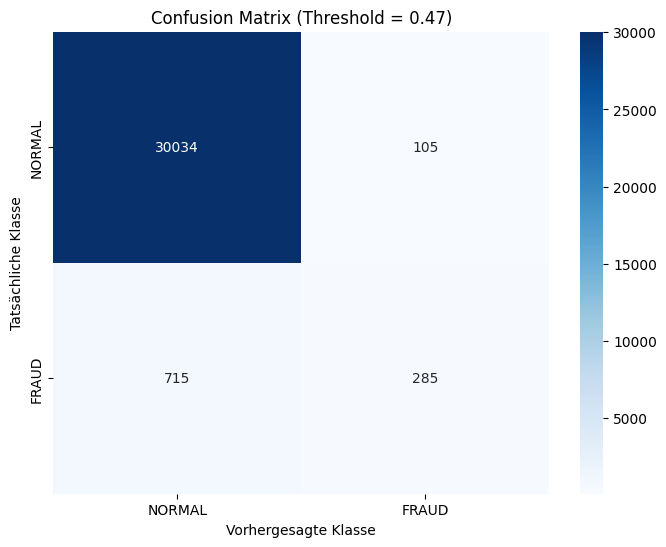



🔄 Vergleich mit Standard-Threshold (0.5):
              precision    recall  f1-score   support

      NORMAL       0.98      1.00      0.99     30139
       FRAUD       0.75      0.27      0.39      1000

    accuracy                           0.97     31139
   macro avg       0.86      0.63      0.69     31139
weighted avg       0.97      0.97      0.97     31139


ROC-AUC (optimierter Threshold): 0.8436
Custom Objective Score (optimierter Threshold 0.47): -4581.77

Beste Parameter des CatBoost-Modells: {'iterations': np.int64(300), 'learning_rate': np.float64(0.07), 'depth': np.int64(6), 'verbose': 0, 'random_state': 42}


In [11]:
# Vorhersagen mit optimalem Threshold
X_test_prep = preprocessor.transform(X_test)
y_scores = final_cat.predict_proba(X_test_prep)[:, 1]
y_pred_optimized = (y_scores >= best_thresh).astype(int)

# 1. Classification Report
print("\n\n🔍 Classification Report (optimierter Threshold):")
print(classification_report(y_test, y_pred_optimized, target_names=["NORMAL", "FRAUD"]))

# 2. Confusion Matrix als Text
print("\n\n📊 Confusion Matrix (optimierter Threshold):")
cm = confusion_matrix(y_test, y_pred_optimized)
print(cm)

# 3. Confusion Matrix als Plot
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=["NORMAL", "FRAUD"], 
            yticklabels=["NORMAL", "FRAUD"])
plt.title(f'Confusion Matrix (Threshold = {best_thresh:.2f})')
plt.ylabel('Tatsächliche Klasse')
plt.xlabel('Vorhergesagte Klasse')
plt.show()

# Zusätzlich: Vergleich mit Standard-Threshold (0.5)
print("\n\n🔄 Vergleich mit Standard-Threshold (0.5):")
y_pred_standard = final_cat.predict(X_test_prep)
print(classification_report(y_test, y_pred_standard, target_names=["NORMAL", "FRAUD"]))

# Metriken für den optimierten Threshold
roc_auc_optimized = roc_auc_score(y_test, y_scores)
print(f"\nROC-AUC (optimierter Threshold): {roc_auc_optimized:.4f}")
print(f"Custom Objective Score (optimierter Threshold {best_thresh:.2f}): {best_custom_score:.2f}")
print(f"\nBeste Parameter des CatBoost-Modells: {best_params_cat}")

# Parameter Speicher

In [12]:
# --- 1. Ordner und Zeitstempel vorbereiten ---

# Relativen Pfad für den Ausgabeordner definieren
output_dir = './weights'

# Sicherstellen, dass der Ordner existiert. Wenn nicht, wird er erstellt.
os.makedirs(output_dir, exist_ok=True)

# Aktuellen Zeitstempel für den Dateinamen erstellen (z.B. "20250622_162350")
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

In [ ]:
# --- 2. Dynamische Dateinamen definieren ---

# Die Dateinamen werden jetzt mit dem Ordnerpfad und dem Zeitstempel zusammengesetzt
# Beachte die Dateiendungen .cbm für das CatBoost-Modell und .joblib für den Preprocessor
model_native_path = os.path.join(output_dir, f'final_catboost_model_{timestamp}.cbm')
preprocessor_joblib_path = os.path.join(output_dir, f'preprocessor_{timestamp}.joblib')


print(f"Speichere Modell unter: {model_native_path}")
print(f"Speichere Preprocessor unter: {preprocessor_joblib_path}")

Speichere Modell unter: ./weights\final_catboost_model_20250622_174142.cbm
Speichere Preprocessor unter: ./weights\preprocessor_20250622_174142.joblib


In [14]:
# --- 3. Speichern der Dateien ---

# Trainiertes CatBoost-Modell mit der nativen Funktion speichern
final_cat.save_model(model_native_path)

# Preprocessor mit joblib speichern
joblib.dump(preprocessor, preprocessor_joblib_path)

['./weights\\preprocessor_20250622_174142.joblib']

## Beispiel zum Model laden

In [15]:
# Leeres Modell-Objekt erstellen und das trainierte Modell laden
loaded_model_native = CatBoostClassifier()
loaded_model_native.load_model(model_native_path)

# Preprocessor laden
loaded_preprocessor_joblib = joblib.load(preprocessor_joblib_path)

print("Modell und Preprocessor erfolgreich nativ/joblib geladen.")


# --- 2. Vorhersage auf neuen Daten ---
# (Die gleichen Beispieldaten wie oben können hier verwendet werden)
new_data = pd.DataFrame({'feature_1': [10.5], 'feature_2': ['A'], 'feature_3': [100]})
new_data_prep = loaded_preprocessor_joblib.transform(new_data)
prediction = loaded_model_native.predict(new_data_prep)
print(f"\nVorhersage: {'FRAUD' if prediction[0] == 1 else 'NORMAL'}")

Modell und Preprocessor erfolgreich nativ/joblib geladen.


ValueError: columns are missing: {'n_lines', 'transaction_lines_details', 'location', 'opening_date', 'total_amount', 'transaction_end', 'payment_medium', 'customer_feedback', 'cash_desk', 'transaction_start'}

## Ergebnis

Der CatBoostClassifier erreicht eine hohe Präzision von 0.73 für Betrugsfälle (FRAUD). Bei den Betrugsfällen liegt der Recall bei 0.28, was zeigt, dass etwa 28% aller tatsächlichen Betrugsfälle erkannt werden. Die Gesamtgenauigkeit (accuracy) beträgt 0.97, während die ROC-AUC von 0.8436 auf eine gute Trennschärfe des Modells hindeutet. Die Konfusionsmatrix zeigt 30034 richtig klassifizierte normale Transaktionen (TN) und 285 richtig erkannte Betrugsfälle (TP), bei 105 falschen Alarmen (FP) und 715 übersehenen Betrugsfällen (FN). Der optimierte Schwellenwert von 0.47 (anstatt des Standardwerts 0.5) wurde durch die Threshold-Optimierung bestimmt, um die spezielle Zielfunktion zu maximieren. Diese berücksichtigt die finanziellen Auswirkungen verschiedener Fehlklassifikationen und ergibt im vorliegenden Fall einen Zielfunktionswert von -4581.77.

- Bester Parameter: {'iterations': 300, 'learning_rate': 0.07, 'depth': 6, 'verbose': 0, 'random_state': 42}
- Optimaler Threshold: 0.47 mit Custom Score: -4581.77